# Perigo Mine Site (Colorado, 2024) — Exploratory Data Analysis

Data source: Manning, Runkel, Ball, Mcgee, Romero-Matos, Muñoz-Sepúlveda (2026),
*Geochemistry and Environmental Tracer Data for Groundwater and Stream Water from
the Perigo Mine Site, Colorado, 2024*, USGS data release,
https://doi.org/10.5066/P143OCZP

This notebook loads the six data tables, cleans them (the release uses `-9999`
as a "no data" sentinel), merges the sample-level tables together, and produces
summary statistics and exploratory plots:

1. Load & clean all tables
2. Site map (springs, wells, stream sites, portal)
3. Water-chemistry summary statistics
4. Major-ion composition by site type
5. Trace-element boxplots (mine-indicator metals)
6. Correlation heatmap of major chemistry parameters
7. Conductivity time series from slug tests
8. Streamflow & metal-load profile down the study reach (mine-contamination diagnostic)

> Edit `DATA_DIR` below if you move the CSV files.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)

DATA_DIR = "."  # folder containing the Table*.csv files

NODATA = -9999  # sentinel value used throughout this data release


## 1. Load & clean tables

All `-9999` sentinel values are converted to `NaN` so pandas/plotting treat them as missing.

In [24]:
def load_clean(fname):
    df = pd.read_csv(f"{DATA_DIR}/{fname}")
    # drop fully-empty trailing columns (Table4 has two blank columns)
    df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
    # replace numeric no-data sentinel with NaN
    num_cols = df.select_dtypes(include="number").columns
    df[num_cols] = df[num_cols].replace(NODATA, np.nan)
    return df

sites   = load_clean("Table1_SampleSites.csv")
chem    = load_clean("Table2_WaterChemistry.csv")
tracers = load_clean("Table3_WaterEnvtTracers.csv")
slug_ts = load_clean("Table4_SlugConductivity.csv")
slug_res= load_clean("Table5_SlugResults.csv")
loads   = load_clean("Table6_StreamflowLoad.csv")

for name, df in [("Sites", sites), ("Chemistry", chem), ("Tracers", tracers),
                  ("Slug conductivity ts", slug_ts), ("Slug results", slug_res),
                  ("Streamflow/load", loads)]:
    print(f"{name:22s} {df.shape[0]:5d} rows x {df.shape[1]:4d} cols")


Sites                     50 rows x   10 cols
Chemistry                 67 rows x  150 cols
Tracers                   31 rows x   36 cols
Slug conductivity ts    5914 rows x    4 cols
Slug results               8 rows x    8 cols
Streamflow/load           16 rows x  145 cols


In [25]:
# parse dates where present
for df, col in [(chem, "Date"), (tracers, "Date_Collected"),
                 (slug_ts, "Date _SlugAddition"), (slug_res, "Date _SlugAddition")]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

sites.head()


,SiteID,SiteType,Description,Latitude,Longitude,Elev_masl,Dist_m,ScrnBot_m_bgs,ScrnTop_m_bgs,WellDiam_cm
0,P5,Bedrock Well,Bedrock monitoring well P5,39.88051,-105.53151,2969.0,NaN,38.7,32.6,5.1
1,P8,Bedrock Well,Bedrock monitoring well P8,39.88045,-105.53401,3053.0,NaN,100.6,30.5,5.1
2,P9A,Bedrock Well,Bedrock monitoring well P9A,39.88070,-105.53109,2966.0,NaN,74.9,68.8,1.9
3,P9B,Bedrock Well,Bedrock monitoring well P9B,39.88070,-105.53109,2966.0,NaN,47.2,41.1,1.9
4,P9C,Bedrock Well,Bedrock monitoring well P9C,39.88070,-105.53109,2966.0,NaN,34.3,28.3,1.9


## 2. Site map

Quick look at where every site sits (springs, wells, stream sites, portal, etc.), colored by `SiteType`.

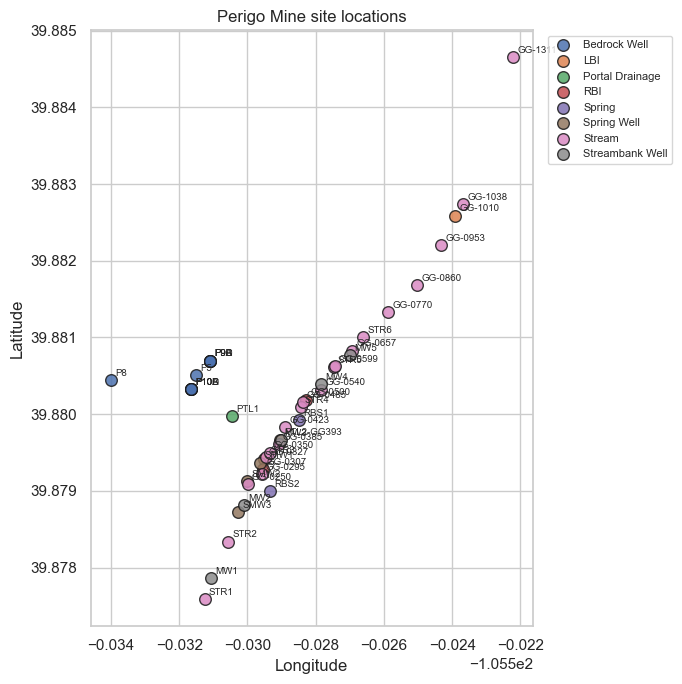

In [26]:
fig, ax = plt.subplots(figsize=(7, 7))
for stype, grp in sites.groupby("SiteType"):
    ax.scatter(grp["Longitude"], grp["Latitude"], label=stype, s=70, edgecolor="k", alpha=0.85)
    for _, r in grp.iterrows():
        ax.annotate(r["SiteID"], (r["Longitude"], r["Latitude"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Perigo Mine site locations")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## 3. Water chemistry summary statistics

Field parameters and major ions across all samples.

In [27]:
field_params = ["SpC_uS_cm", "pH", "T_celsius", "DO_mg_L", "Alkalinity_mg_L_HCO3",
                "F_mg_L", "Cl_mg_L", "SO4_mg_L", "Br_mg_L", "NO3_mg_L", "Fe_T_mg_L"]
field_params = [c for c in field_params if c in chem.columns]

chem[field_params].describe().T


,count,mean,std,min,25%,50%,75%,max
SpC_uS_cm,64.0,279.550000,191.225003,28.000,95.75000,262.0000,426.00000,785.00
pH,56.0,6.308393,0.917012,3.730,5.83750,6.5300,6.97750,7.86
T_celsius,62.0,7.277419,2.796978,3.600,5.35000,6.4000,8.47500,17.80
DO_mg_L,41.0,5.146341,2.839727,0.400,2.20000,5.9000,7.80000,8.80
Alkalinity_mg_L_HCO3,57.0,15.673684,22.964021,-6.100,1.80000,14.6000,17.30000,91.20
F_mg_L,58.0,0.635172,0.586152,-0.050,0.10625,0.3545,1.26250,1.69
Cl_mg_L,58.0,0.477948,0.674190,0.076,0.32000,0.3300,0.37575,4.99
SO4_mg_L,58.0,113.309259,104.990005,-0.100,12.15000,68.4500,225.00000,333.00
Br_mg_L,58.0,5.286638,16.065424,-0.050,-0.00500,0.0080,4.24500,75.90
NO3_mg_L,58.0,-0.019931,0.028849,-0.050,-0.05000,-0.0050,0.00500,0.05


In [28]:
summary_by_type = chem.groupby("SiteType")[field_params].median(numeric_only=True)
summary_by_type


,SpC_uS_cm,pH,T_celsius,DO_mg_L,Alkalinity_mg_L_HCO3,F_mg_L,Cl_mg_L,SO4_mg_L,Br_mg_L,NO3_mg_L,Fe_T_mg_L
SiteType,,,,,,,,,,,
-9999,NaN,NaN,NaN,NaN,3.10,-0.0275,0.0880,-0.0165,-0.0275,-0.0215,NaN
Bedrock Well,262.0,7.315,11.60,2.25,68.20,0.3065,0.5710,48.5000,0.0090,-0.0050,NaN
LBI,464.5,6.105,7.30,8.00,6.35,0.8850,0.3510,232.5000,-0.0225,-0.0500,3.22
Portal Drainage,645.0,3.730,7.95,5.85,-6.10,1.6700,0.3630,333.0000,0.0060,0.0080,NaN
RBI,61.5,7.035,5.00,NaN,19.25,0.1000,0.3450,10.5500,-0.0500,-0.0500,NaN
Spring,63.5,6.950,4.30,8.45,18.70,0.1105,0.4770,10.5850,0.0055,0.0080,NaN
Spring Well,100.5,6.640,5.15,6.40,15.60,0.1430,0.3600,26.6000,0.0055,0.0200,NaN
Stream,421.5,5.955,6.20,8.35,2.05,0.9960,0.3205,191.0000,4.4800,-0.0500,1.53
Streambank Well,282.0,5.670,6.45,4.95,1.80,0.7300,0.3200,158.0000,0.0080,-0.0050,NaN


## 4. Major-ion composition by site type

Specific conductance and sulfate are strong indicators of mine-influenced water at Perigo (acid-rock-drainage sites tend to run high SpC / high SO4, low pH).

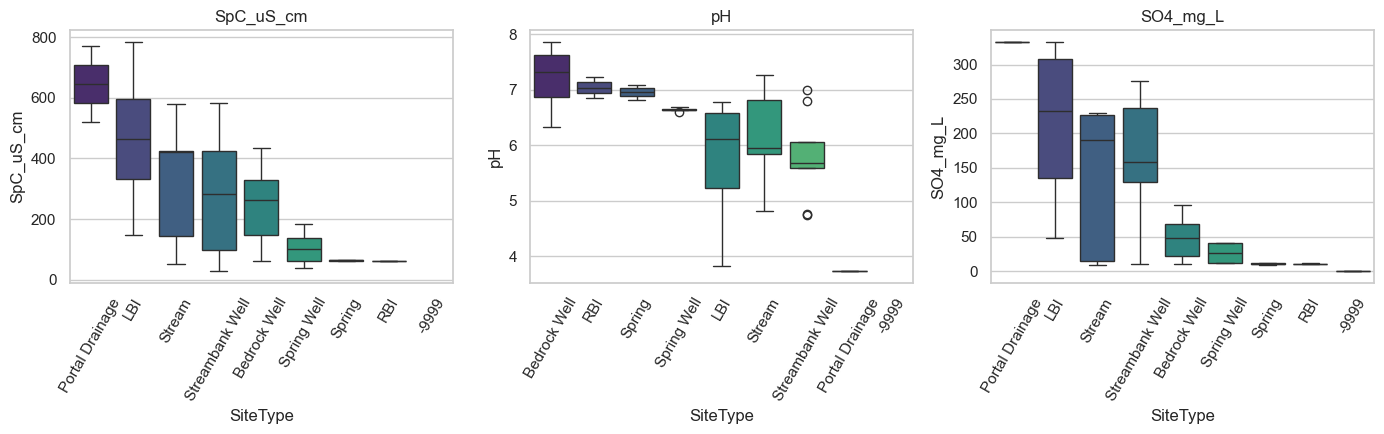

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, col in zip(axes, ["SpC_uS_cm", "pH", "SO4_mg_L"]):
    order = chem.groupby("SiteType")[col].median().sort_values(ascending=False).index
    sns.boxplot(data=chem, x="SiteType", y=col, order=order, ax=ax, palette="viridis")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()


## 5. Trace-element boxplots (mine-indicator metals)

Zn, Cu, Cd, and Pb are classic acid-mine-drainage indicator metals. Values here
use the filtered (`_fa`) fraction in µg/L, log-scaled since concentrations span
several orders of magnitude across site types.

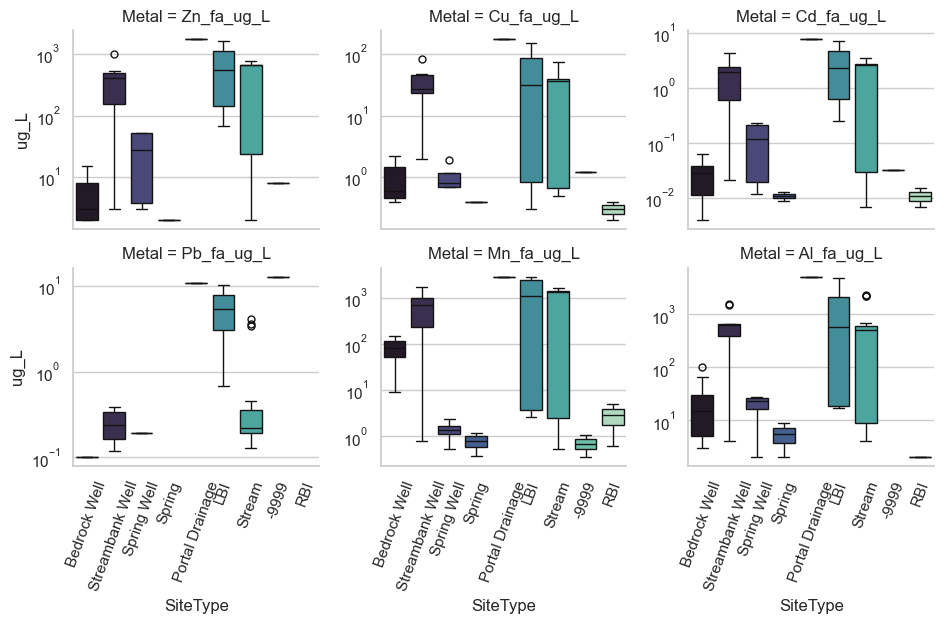

In [30]:
metals = ["Zn_fa_ug_L", "Cu_fa_ug_L", "Cd_fa_ug_L", "Pb_fa_ug_L", "Mn_fa_ug_L", "Al_fa_ug_L"]
metals = [m for m in metals if m in chem.columns]

melt = chem.melt(id_vars=["SiteType"], value_vars=metals, var_name="Metal", value_name="ug_L")
melt = melt[melt["ug_L"] > 0]  # log scale needs positive values

g = sns.catplot(data=melt, x="SiteType", y="ug_L", col="Metal", col_wrap=3,
                 kind="box", palette="mako", height=3.2, sharey=False)
g.set(yscale="log")
for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
plt.show()


## 6. Correlation heatmap

Relationships among field parameters, major ions, and key trace metals.

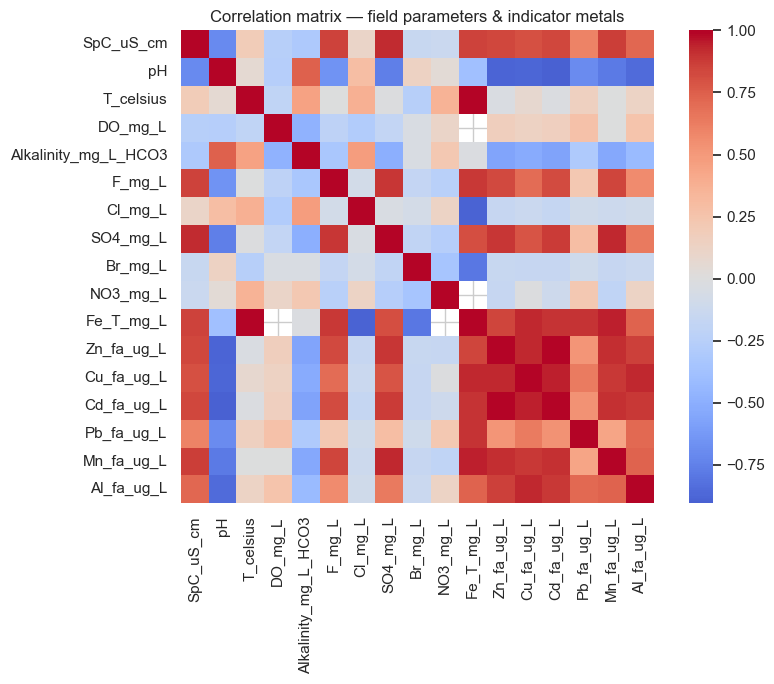

In [31]:
corr_cols = field_params + [m for m in metals if m not in field_params]
corr = chem[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True, ax=ax)
ax.set_title("Correlation matrix — field parameters & indicator metals")
plt.tight_layout()
plt.show()


## 7. Slug-test conductivity time series

High-frequency background-subtracted specific conductance (BCSC) recorded during each salt-slug streamflow measurement.

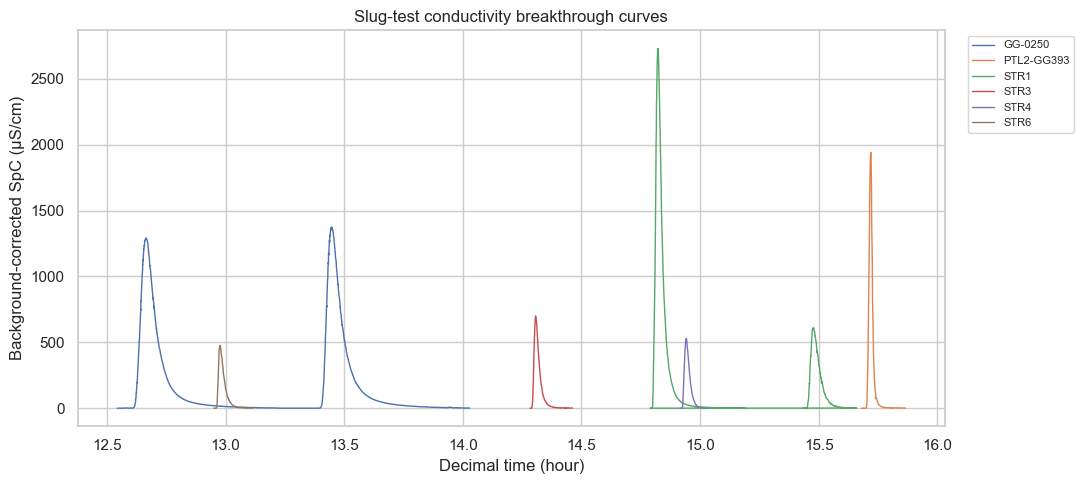

In [32]:
fig, ax = plt.subplots(figsize=(11, 5))
for sid, grp in slug_ts.groupby("SiteID"):
    ax.plot(grp["Dectime_hour"], grp["BCSC_uS_cm"], label=sid, linewidth=1)

ax.set_xlabel("Decimal time (hour)")
ax.set_ylabel("Background-corrected SpC (µS/cm)")
ax.set_title("Slug-test conductivity breakthrough curves")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## 8. Streamflow & metal-load profile down the study reach

`Table6_StreamflowLoad.csv` gives synoptic streamflow and constituent loads at
points progressing downstream (`Dist_m`). Comparing streamflow gain to the
gain in metal load pinpoints where contaminated groundwater is entering the
stream — the core diagnostic of this study.

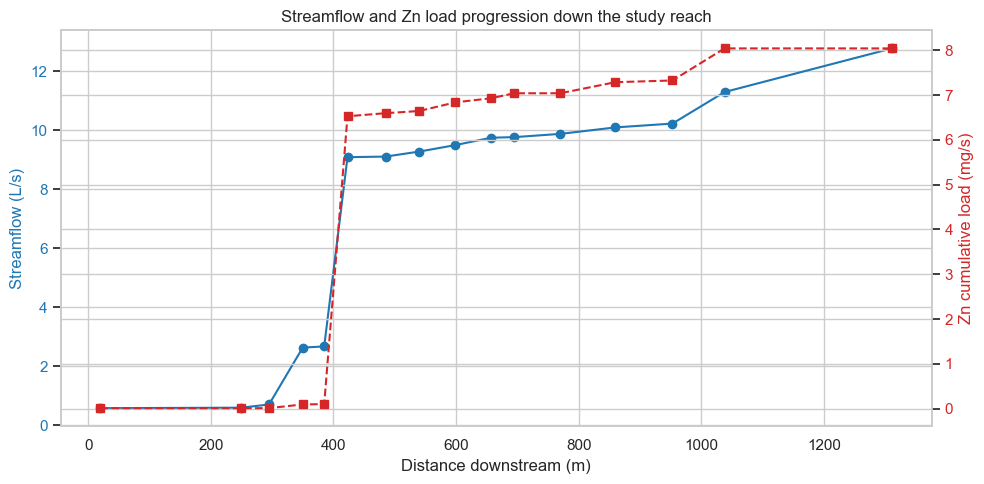

In [33]:
loads_sorted = loads.sort_values("Dist_m")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(loads_sorted["Dist_m"], loads_sorted["Streamflow_L_s"], "o-", color="tab:blue", label="Streamflow (L/s)")
ax1.set_xlabel("Distance downstream (m)")
ax1.set_ylabel("Streamflow (L/s)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
if "Zn_cumulative_mg_s" in loads_sorted.columns:
    ax2.plot(loads_sorted["Dist_m"], loads_sorted["Zn_cumulative_mg_s"], "s--", color="tab:red", label="Zn cumulative load (mg/s)")
    ax2.set_ylabel("Zn cumulative load (mg/s)", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("Streamflow and Zn load progression down the study reach")
plt.tight_layout()
plt.show()


In [34]:
# Which reach segments contribute the most Zn load? (Al/Zn/Cu contribution %)
contrib_cols = [c for c in loads.columns if c.endswith("_contribution_percent")]
top_contrib = loads_sorted.set_index("SiteID")[contrib_cols]
top_contrib.style.background_gradient(cmap="OrRd", axis=0)


,Al_contribution_percent,Ba_contribution_percent,Be_contribution_percent,Ca_contribution_percent,Cd_contribution_percent,Ce_contribution_percent,Cl_contribution_percent,Co_contribution_percent,Cu_contribution_percent,Dy_contribution_percent,Er_contribution_percent,Eu_contribution_percent,F_contribution_percent,Fe_contribution_percent,Gd_contribution_percent,K_contribution_percent,La_contribution_percent,Li_contribution_percent,Mg_contribution_percent,Mn_contribution_percent,Mo_contribution_percent,Nd_contribution_percent,Ni_contribution_percent,Pb_contribution_percent,Pr_contribution_percent,Rb_contribution_percent,Si_contribution_percent,Sm_contribution_percent,SO4_contribution_percent,Sr_contribution_percent,U_contribution_percent,W_contribution_percent,Y_contribution_percent,Yb_contribution_percent,Zn_contribution_percent
SiteID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
STR1,0.200000,2.500000,0.100000,0.400000,0.000000,0.100000,4.000000,0.003700,0.100000,0.200000,nan,nan,0.200000,0.000000,0.100000,1.800000,0.100000,0.200000,0.500000,0.000000,2.200000,0.100000,0.000000,0.300000,0.100000,0.400000,2.400000,0.200000,0.200000,0.600000,0.000000,0.100000,0.200000,0.200000,0.200000
GG-0250,-0.100000,0.400000,0.000000,0.000000,0.000000,0.000000,0.400000,0.000100,0.000000,0.000000,0.300000,nan,0.200000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,-0.300000,0.000000,0.000000,-0.100000,0.000000,-0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,-0.100000
GG-0295,0.000000,1.500000,0.000000,0.200000,0.000000,0.000000,1.000000,0.000300,0.000000,0.100000,-0.100000,0.400000,-0.100000,0.000000,0.100000,0.600000,0.100000,0.000000,0.300000,0.000000,0.400000,0.100000,0.000000,0.300000,0.000000,0.100000,0.500000,0.100000,0.000000,0.300000,0.000000,1.600000,0.000000,0.000000,0.000000
GG-0350,0.400000,15.300000,0.200000,3.600000,0.700000,0.300000,14.800000,0.035000,0.500000,1.000000,0.700000,1.000000,1.200000,0.600000,0.500000,8.900000,0.900000,1.000000,4.200000,0.100000,6.300000,0.600000,1.000000,0.900000,0.800000,0.900000,8.500000,0.800000,2.100000,4.300000,0.100000,-1.100000,1.400000,0.800000,1.000000
GG-0385,0.000000,0.700000,0.300000,0.200000,0.000000,0.000000,0.900000,0.013700,0.000000,0.000000,1.000000,0.000000,0.000000,-0.200000,0.700000,0.300000,-0.400000,0.000000,0.100000,0.000000,-1.300000,0.100000,0.000000,-0.100000,0.000000,0.000000,0.000000,0.400000,0.100000,0.100000,0.000000,1.400000,-0.200000,1.100000,0.100000
GG-0423,86.300000,37.500000,63.100000,70.500000,74.000000,90.900000,44.500000,93.000000,87.800000,77.500000,74.300000,76.800000,80.200000,93.800000,81.300000,59.000000,83.100000,75.000000,65.500000,87.500000,87.300000,85.900000,75.100000,90.500000,82.400000,84.000000,61.900000,79.400000,70.900000,67.600000,92.600000,86.800000,75.100000,65.600000,79.900000
GG-0485,0.200000,1.900000,2.300000,-0.800000,-4.500000,-2.300000,-1.900000,-2.400000,-3.300000,-4.000000,-3.300000,0.200000,-5.100000,-5.300000,-13.400000,-1.500000,0.200000,3.100000,-4.000000,-2.600000,-14.800000,-2.500000,-3.000000,2.000000,-2.100000,-2.000000,-0.400000,1.500000,0.500000,-1.200000,2.700000,0.200000,2.700000,7.700000,0.800000
GG-0540,2.300000,-0.300000,1.200000,1.100000,1.000000,5.400000,3.300000,0.300000,0.400000,-1.400000,12.000000,-12.600000,-2.900000,-6.100000,-1.000000,1.700000,2.000000,-3.000000,3.000000,-1.800000,1.500000,1.000000,1.400000,-9.700000,3.900000,-0.700000,0.200000,0.200000,-0.600000,0.000000,-9.800000,-5.200000,5.000000,-2.400000,0.600000
GG-0599,-1.300000,4.300000,2.700000,2.100000,5.100000,-6.000000,1.600000,-0.500000,1.500000,4.600000,-5.300000,1.500000,2.800000,-2.800000,7.500000,3.400000,2.500000,3.300000,3.300000,1.900000,-3.300000,-5.000000,5.100000,2.600000,-2.800000,-2.600000,4.000000,-13.100000,3.400000,2.800000,-3.900000,-0.600000,3.000000,1.700000,2.400000


## Next steps / ideas

- Build a Piper diagram or Stiff diagram for full major-ion water-type classification.
- Join `Table3` tracer data (tritium, noble gases, δ¹⁸O/δ²H) to estimate groundwater
  recharge elevation and residence time, and compare across well types.
- Regress indicator-metal concentration against distance/streamflow to model
  loading from the mine workings specifically.
- Export cleaned, merged tables to a single Excel workbook or database for GIS use.


## 9. Piper diagram — major-ion water-type classification

A [Piper diagram](https://en.wikipedia.org/wiki/Piper_diagram) projects cation \
(Ca²⁺, Mg²⁺, Na⁺+K⁺) and anion (HCO₃⁻, SO₄²⁻, Cl⁻) milliequivalent \
fractions onto two ternary sub-plots that are then combined into a central \
diamond.  The diagram is drawn from scratch with matplotlib — no external \
geochemistry library is needed.


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/piper_diagram.png'

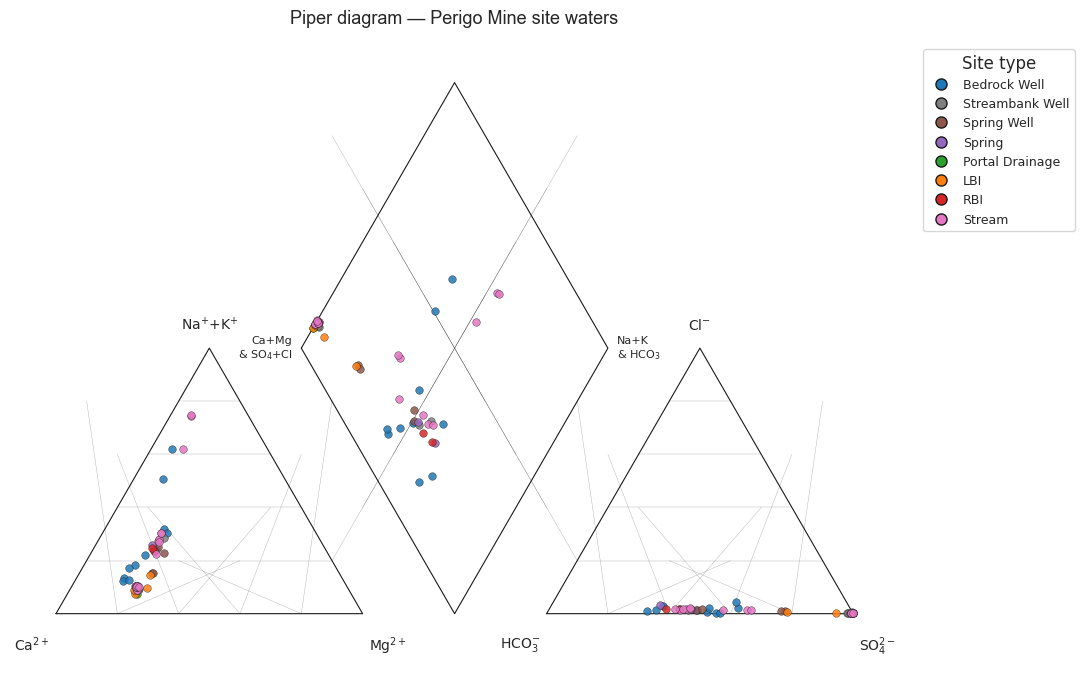

In [35]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# ── 1. Unit conversions (all values to meq/L) ──────────────────────────────
EW = {
    "Ca": 20.04, "Mg": 12.15, "Na": 22.99, "K": 39.10,   # cations
    "HCO3": 61.02, "Cl": 35.45, "SO4": 48.03             # anions
}

def ug_L_to_meq(series, ew):
    """µg/L → meq/L (ew = equivalent weight, g/mol)"""
    return series.clip(lower=0) / 1000 / ew

def mg_L_to_meq(series, ew):
    """mg/L → meq/L"""
    return series.clip(lower=0) / ew

p = chem.copy()

p["Ca_meq"] = ug_L_to_meq(p["Ca_fa_ug_L"], EW["Ca"])
p["Mg_meq"] = ug_L_to_meq(p["Mg_fa_ug_L"], EW["Mg"])
p["Na_meq"] = ug_L_to_meq(p["Na_fa_ug_L"], EW["Na"])
p["K_meq"] = ug_L_to_meq(p["K_fa_ug_L"], EW["K"])
p["HCO3_meq"] = mg_L_to_meq(p["Alkalinity_mg_L_HCO3"], EW["HCO3"])
p["Cl_meq"] = mg_L_to_meq(p["Cl_mg_L"], EW["Cl"])
p["SO4_meq"] = mg_L_to_meq(p["SO4_mg_L"], EW["SO4"])

p["NaK_meq"] = p["Na_meq"] + p["K_meq"]
p["cat_sum"] = p["Ca_meq"] + p["Mg_meq"] + p["NaK_meq"]
p["ani_sum"] = p["HCO3_meq"] + p["Cl_meq"] + p["SO4_meq"]

# % meq fractions
p["Ca_pct"] = 100 * p["Ca_meq"] / p["cat_sum"]
p["Mg_pct"] = 100 * p["Mg_meq"] / p["cat_sum"]
p["NaK_pct"] = 100 * p["NaK_meq"] / p["cat_sum"]
p["HCO3_pct"] = 100 * p["HCO3_meq"] / p["ani_sum"]
p["SO4_pct"] = 100 * p["SO4_meq"] / p["ani_sum"]
p["Cl_pct"] = 100 * p["Cl_meq"] / p["ani_sum"]

piper_df = p.dropna(subset=["Ca_pct", "Mg_pct", "NaK_pct", "HCO3_pct", "SO4_pct", "Cl_pct"])

# ── 2. Coordinate helpers ──────────────────────────────────────────────────
h = np.sqrt(3) / 2       # equilateral triangle height, side length = 1
OFFSET = 1.6             # horizontal gap between the two triangles (widened to stop label collisions)

def tern_to_xy(a, b, c):
    """Ternary (a,b,c summing to 100) → Cartesian (x,y) for a triangle with
    vertex a at (0,0), vertex b at (1,0), vertex c at (0.5,h)."""
    x = 0.5 * (2 * b + c) / 100.0
    y = h * c / 100.0
    return x, y

def cation_xy(row):
    # vertices: Ca (left), Mg (right), Na+K (top)
    return tern_to_xy(row["Ca_pct"], row["Mg_pct"], row["NaK_pct"])

def anion_xy(row):
    # vertices: HCO3 (left), SO4 (right), Cl (top)
    return tern_to_xy(row["HCO3_pct"], row["SO4_pct"], row["Cl_pct"])

def diamond_xy(row):
    """Correct Piper diamond projection.
    Horizontal axis: %(Na+K) -- 0 at left vertex (Ca+Mg dominant) to 1 at right vertex (Na+K dominant)
    Vertical axis:   %(Cl+SO4) -- 0 at bottom vertex (HCO3 dominant) to 1 at top vertex (Cl+SO4 dominant)
    """
    x_d = row["NaK_pct"] / 100.0
    y_d = (row["Cl_pct"] + row["SO4_pct"]) / 100.0
    x = OFFSET / 2 + 0.5 + 0.5 * (x_d - y_d)
    y = h * (x_d + y_d)
    return x, y

# ── 3. Draw Piper ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
ax.set_aspect("equal")
ax.axis("off")
plt.rcParams["font.family"] = "DejaVu Sans"   # font that reliably has the sub/superscript glyphs we need

def triangle(ax, x0, y0, labels=None, label_va="top"):
    pts = np.array([[x0, y0], [x0 + 1, y0], [x0 + 0.5, y0 + h], [x0, y0]])
    ax.plot(pts[:, 0], pts[:, 1], "k-", lw=0.8)

    for pct in [20, 40, 60, 80]:
        f = pct / 100.0
        ax.plot([x0 + f, x0 + 0.5 * f + 0.5], [y0, y0 + h * f], "k-", lw=0.3, alpha=0.35)
        ax.plot([x0 + 1 - f, x0 + 0.5 - 0.5 * f], [y0, y0 + h * f], "k-", lw=0.3, alpha=0.35)
        ax.plot([x0 + 0.5 * f, x0 + 1 - 0.5 * f], [y0 + h * f, y0 + h * f], "k-", lw=0.3, alpha=0.35)

    if labels:
        ax.text(x0 - 0.02, y0 - 0.07, labels[0], ha="right", va=label_va, fontsize=10)
        ax.text(x0 + 1.02, y0 - 0.07, labels[1], ha="left", va=label_va, fontsize=10)
        ax.text(x0 + 0.5, y0 + h + 0.05, labels[2], ha="center", va="bottom", fontsize=10)

# Cation triangle (bottom left)
triangle(ax, 0, 0, labels=["Ca$^{2+}$", "Mg$^{2+}$", "Na$^{+}$+K$^{+}$"])

# Anion triangle (bottom right)
triangle(ax, OFFSET, 0, labels=["HCO$_3^{-}$", "SO$_4^{2-}$", "Cl$^{-}$"])

# Diamond (top centre)
diam = np.array([
    [OFFSET / 2 + 0.0, h],
    [OFFSET / 2 + 0.5, 2 * h],
    [OFFSET / 2 + 1.0, h],
    [OFFSET / 2 + 0.5, 0],
    [OFFSET / 2 + 0.0, h],
])
ax.plot(diam[:, 0], diam[:, 1], "k-", lw=0.8)

# diamond gridlines (20/40/60/80%) along both diagonals
for pct in [20, 40, 60, 80]:
    f = pct / 100.0
    cx0, cy0 = OFFSET / 2 + 0.5, h
    # lines parallel to the bottom-left/top-right edges (constant x_d - y_d)
    p1 = (OFFSET / 2 + 0.5 * f, h * f)
    p2 = (OFFSET / 2 + 0.5 + 0.5 * f, h + h * f)
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], "k-", lw=0.3, alpha=0.35)
    p1 = (OFFSET / 2 + 1 - 0.5 * f, h * f)
    p2 = (OFFSET / 2 + 0.5 - 0.5 * f, h + h * f)
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], "k-", lw=0.3, alpha=0.35)

# diamond vertex labels
ax.text(OFFSET / 2 - 0.03, h, "Ca+Mg\n& SO$_4$+Cl", ha="right", va="center", fontsize=8)
ax.text(OFFSET / 2 + 1.03, h, "Na+K\n& HCO$_3$", ha="left", va="center", fontsize=8)

# ── 4. Plot samples ────────────────────────────────────────────────────────
palette = sns.color_palette("tab10", n_colors=piper_df["SiteType"].nunique())
cmap = dict(zip(sorted(piper_df["SiteType"].unique()), palette))

handles = {}
for _, row in piper_df.iterrows():
    st = row["SiteType"]
    if st == "-9999":
        continue
    c = cmap.get(st, "grey")

    cx, cy = cation_xy(row)
    ax.scatter(cx, cy, color=c, s=30, edgecolors="k", linewidths=0.3, zorder=5, alpha=0.85)

    axv, ayv = anion_xy(row)
    ax.scatter(OFFSET + axv, ayv, color=c, s=30, edgecolors="k", linewidths=0.3, zorder=5, alpha=0.85)

    dx, dy = diamond_xy(row)
    ax.scatter(dx, dy, color=c, s=30, edgecolors="k", linewidths=0.3, zorder=5, alpha=0.85)

    if st not in handles:
        handles[st] = Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
                              markeredgecolor="k", markersize=8, label=st)

ax.set_xlim(-0.15, OFFSET + 1.15)
ax.set_ylim(-0.2, 2.15 * h)
ax.set_title("Piper diagram — Perigo Mine site waters", fontsize=13, pad=14)
ax.legend(handles=list(handles.values()), bbox_to_anchor=(1.02, 1), loc="upper left",
          fontsize=9, title="Site type")

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/piper_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Plotted {len(piper_df)} samples.")


## 10. Stable-isotope & environmental-tracer analysis (Table 3)

`Table3_WaterEnvtTracers.csv` contains:
* **δ¹⁸O / δ²H** — stable water isotopes (‰ VSMOW) for recharge-elevation and
  water-source fingerprinting.
* **³H (tritium, TU)** — distinguishes modern (> ~0.5 TU) from sub-modern
  groundwater.
* **Noble gases** (He, Ne, Ar, Kr, Xe) and **SF₆** — dissolved-gas tracers
  for recharge temperature and apparent age.

We join the tracer table to the site table (for elevation) and produce four
sub-analyses.


In [ ]:
# ── Join tracers → sites for elevation ─────────────────────────────────────
tr = tracers.copy()
tr = tr.merge(sites[["SiteID", "Elev_masl"]], on="SiteID", how="left")

# parse dates
tr["Date_Collected"] = pd.to_datetime(tr["Date_Collected"], errors="coerce")

print(tr[["SiteID", "SiteType", "Elev_masl",
          "delta_18O_permil", "delta_2H_permil",
          "3H_TU", "He", "Ne"]].to_string())


        SiteID         SiteType  Elev_masl  delta_18O_permil  delta_2H_permil  3H_TU     He     Ne
0           P5     Bedrock Well     2969.0            -17.88           -136.5    NaN    NaN    NaN
1           P8     Bedrock Well     3053.0            -17.38           -130.7    NaN    NaN    NaN
2          P9A     Bedrock Well     2966.0            -17.25           -129.1   6.02  73.84  210.3
3          P9B     Bedrock Well     2966.0            -17.35           -130.5   5.01  71.71  197.2
4          P9C     Bedrock Well     2966.0            -17.35           -129.8   5.89  69.39  202.1
5          P9D     Bedrock Well     2966.0            -17.21           -127.9  10.28  38.40  163.3
6         P10A     Bedrock Well     2970.0            -16.95           -128.5   5.12  71.72  216.5
7         P10B     Bedrock Well     2970.0            -16.94           -124.7   5.92  78.02  263.0
8         P10C     Bedrock Well     2970.0            -16.78           -126.2   7.70  55.20  201.6
9         

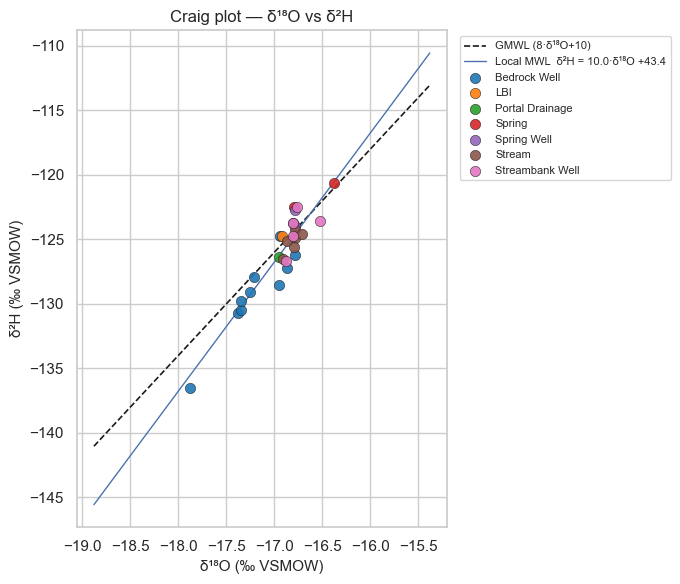

In [ ]:
# ── 10a. δ¹⁸O vs δ²H (Craig plot) ─────────────────────────────────────────
iso = tr.dropna(subset=["delta_18O_permil", "delta_2H_permil"])

fig, ax = plt.subplots(figsize=(7, 6))

# Global Meteoric Water Line (Craig 1961): δ²H = 8·δ¹⁸O + 10
x_range = np.array([iso["delta_18O_permil"].min() - 1,
                     iso["delta_18O_permil"].max() + 1])
ax.plot(x_range, 8 * x_range + 10, "k--", linewidth=1.2, label="GMWL (8·δ¹⁸O+10)")

# Local meteoric water line (best fit through data)
mask = iso["SiteType"].isin(["Stream", "Spring", "Portal Drainage"])
if mask.sum() >= 2:
    m_loc, b_loc = np.polyfit(iso.loc[mask, "delta_18O_permil"],
                               iso.loc[mask, "delta_2H_permil"], 1)
    ax.plot(x_range, m_loc * x_range + b_loc, "b-", linewidth=1,
            label=f"Local MWL  δ²H = {m_loc:.1f}·δ¹⁸O {b_loc:+.1f}")

palette2 = sns.color_palette("tab10", n_colors=iso["SiteType"].nunique())
cmap2 = dict(zip(sorted(iso["SiteType"].unique()), palette2))
for st, grp in iso.groupby("SiteType"):
    c = cmap2.get(st, "grey")
    ax.scatter(grp["delta_18O_permil"], grp["delta_2H_permil"],
               color=c, s=55, edgecolors="k", linewidths=0.4,
               label=st, zorder=4, alpha=0.9)

ax.set_xlabel("δ¹⁸O (‰ VSMOW)", fontsize=11)
ax.set_ylabel("δ²H (‰ VSMOW)", fontsize=11)
ax.set_title("Craig plot — δ¹⁸O vs δ²H", fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


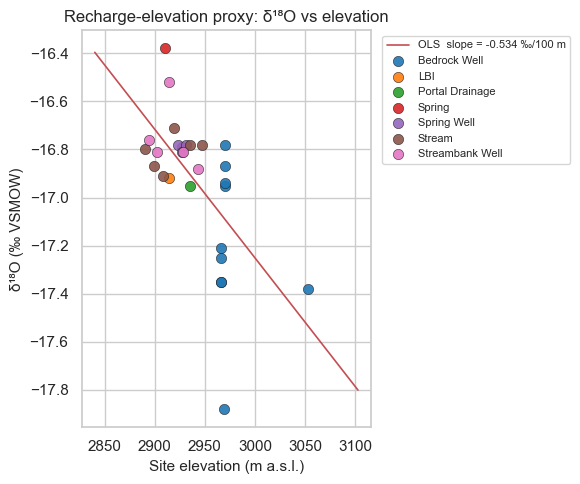

Isotopic lapse rate: -0.534 ‰ per 100 m elevation


In [ ]:
# ── 10b. δ¹⁸O vs elevation — recharge altitude estimate ───────────────────
iso_elev = tr.dropna(subset=["delta_18O_permil", "Elev_masl"])
iso_elev = iso_elev[iso_elev["Elev_masl"].notna()]

fig, ax = plt.subplots(figsize=(6, 5))

if len(iso_elev) >= 3:
    m_e, b_e = np.polyfit(iso_elev["Elev_masl"], iso_elev["delta_18O_permil"], 1)
    elev_range = np.array([iso_elev["Elev_masl"].min() - 50,
                           iso_elev["Elev_masl"].max() + 50])
    ax.plot(elev_range, m_e * elev_range + b_e, "r-", linewidth=1.2,
            label=f"OLS  slope = {m_e*100:.3f} ‰/100 m")

palette3 = sns.color_palette("tab10", n_colors=iso_elev["SiteType"].nunique())
cmap3 = dict(zip(sorted(iso_elev["SiteType"].unique()), palette3))
for st, grp in iso_elev.groupby("SiteType"):
    ax.scatter(grp["Elev_masl"], grp["delta_18O_permil"],
               color=cmap3.get(st, "grey"), s=55, edgecolors="k",
               linewidths=0.4, label=st, zorder=4, alpha=0.9)

ax.set_xlabel("Site elevation (m a.s.l.)", fontsize=11)
ax.set_ylabel("δ¹⁸O (‰ VSMOW)", fontsize=11)
ax.set_title("Recharge-elevation proxy: δ¹⁸O vs elevation", fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

if len(iso_elev) >= 3:
    print(f"Isotopic lapse rate: {m_e*100:.3f} ‰ per 100 m elevation")
    # Indicative recharge elevation if GMWL intercept is used
    # (not attempted without a local precipitation value)


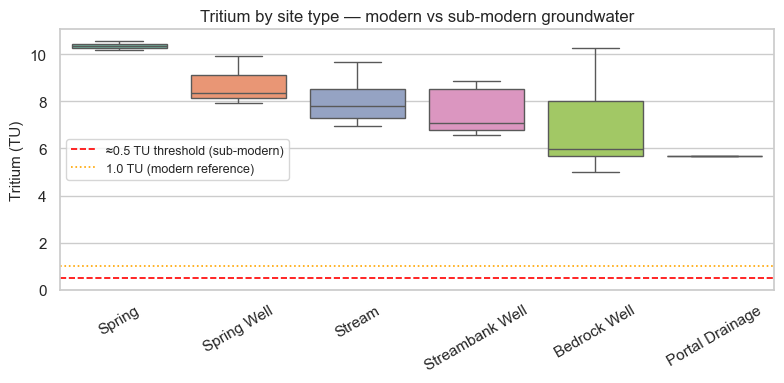

Median ³H by site type:
                 median    min    max  count
SiteType                                    
Bedrock Well       5.97   5.01  10.28      8
Portal Drainage    5.70   5.70   5.70      1
Spring            10.36  10.17  10.56      2
Spring Well        8.35   7.92   9.93      3
Stream             7.79   6.95   9.66      4
Streambank Well    7.07   6.57   8.89      5


In [ ]:
# ── 10c. Tritium (³H) — modern vs sub-modern water ─────────────────────────
h3 = tr.dropna(subset=["3H_TU"])

fig, ax = plt.subplots(figsize=(8, 4))
order_h3 = h3.groupby("SiteType")["3H_TU"].median().sort_values(ascending=False).index
sns.boxplot(data=h3, x="SiteType", y="3H_TU", order=order_h3,
            palette="Set2", ax=ax)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1.2, label="≈0.5 TU threshold (sub-modern)")
ax.axhline(1.0, color="orange", linestyle=":", linewidth=1.2, label="1.0 TU (modern reference)")
ax.set_xlabel("")
ax.set_ylabel("Tritium (TU)", fontsize=11)
ax.set_title("Tritium by site type — modern vs sub-modern groundwater", fontsize=12)
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Median ³H by site type:")
print(h3.groupby("SiteType")["3H_TU"].agg(["median","min","max","count"]).round(2))


Median dissolved noble-gas concentrations by site type (ccSTP/g or similar):


,He,Ne,Ar,Kr,Xe
SiteType,,,,,
Bedrock Well,70.55,201.85,364.4,84.255,12.54
LBI,NaN,NaN,NaN,NaN,NaN
Portal Drainage,36.55,152.80,321.7,78.660,12.27
Spring,35.92,156.30,343.2,84.605,12.92
Spring Well,38.96,169.60,344.9,83.040,12.59
Stream,NaN,NaN,NaN,NaN,NaN
Streambank Well,36.00,153.00,313.3,75.340,11.24


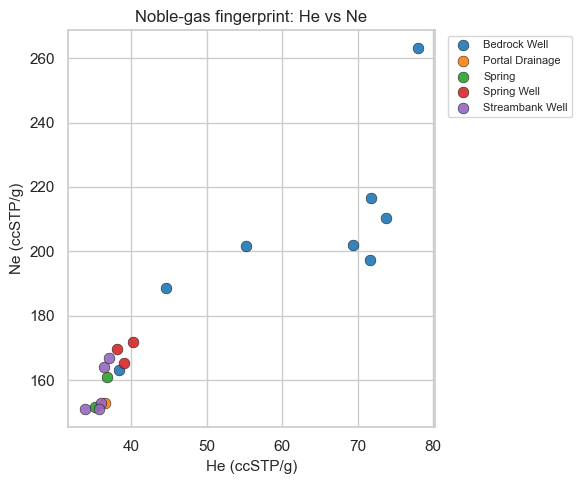

In [ ]:
# ── 10d. Noble-gas summary by site type ────────────────────────────────────
ng_cols = [c for c in ["He", "Ne", "Ar", "Kr", "Xe"] if c in tr.columns]

ng_summary = tr.groupby("SiteType")[ng_cols].median(numeric_only=True).round(3)
print("Median dissolved noble-gas concentrations by site type (ccSTP/g or similar):")
display(ng_summary)

# Simple scatter: He vs Ne coloured by SiteType (noble-gas fingerprint)
ng_plot = tr.dropna(subset=["He","Ne"])
if len(ng_plot) >= 2:
    fig, ax = plt.subplots(figsize=(6, 5))
    palette_ng = sns.color_palette("tab10", n_colors=ng_plot["SiteType"].nunique())
    cmap_ng = dict(zip(sorted(ng_plot["SiteType"].unique()), palette_ng))
    for st, grp in ng_plot.groupby("SiteType"):
        ax.scatter(grp["He"], grp["Ne"], color=cmap_ng.get(st,"grey"),
                   s=60, edgecolors="k", linewidths=0.4, label=st, alpha=0.9)
    ax.set_xlabel("He (ccSTP/g)", fontsize=11)
    ax.set_ylabel("Ne (ccSTP/g)", fontsize=11)
    ax.set_title("Noble-gas fingerprint: He vs Ne", fontsize=12)
    ax.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


## 11. Metal-loading regression vs. distance and streamflow

`Table6_StreamflowLoad.csv` provides synoptic streamflow and cumulative metal
loads at each measurement point along the stream (sorted by `Dist_m`).  
We fit linear regressions of **cumulative load vs. distance** to quantify how
quickly each AMD-indicator metal accumulates per metre of stream, and identify
the dominant source reaches from the per-reach **contribution %** columns.


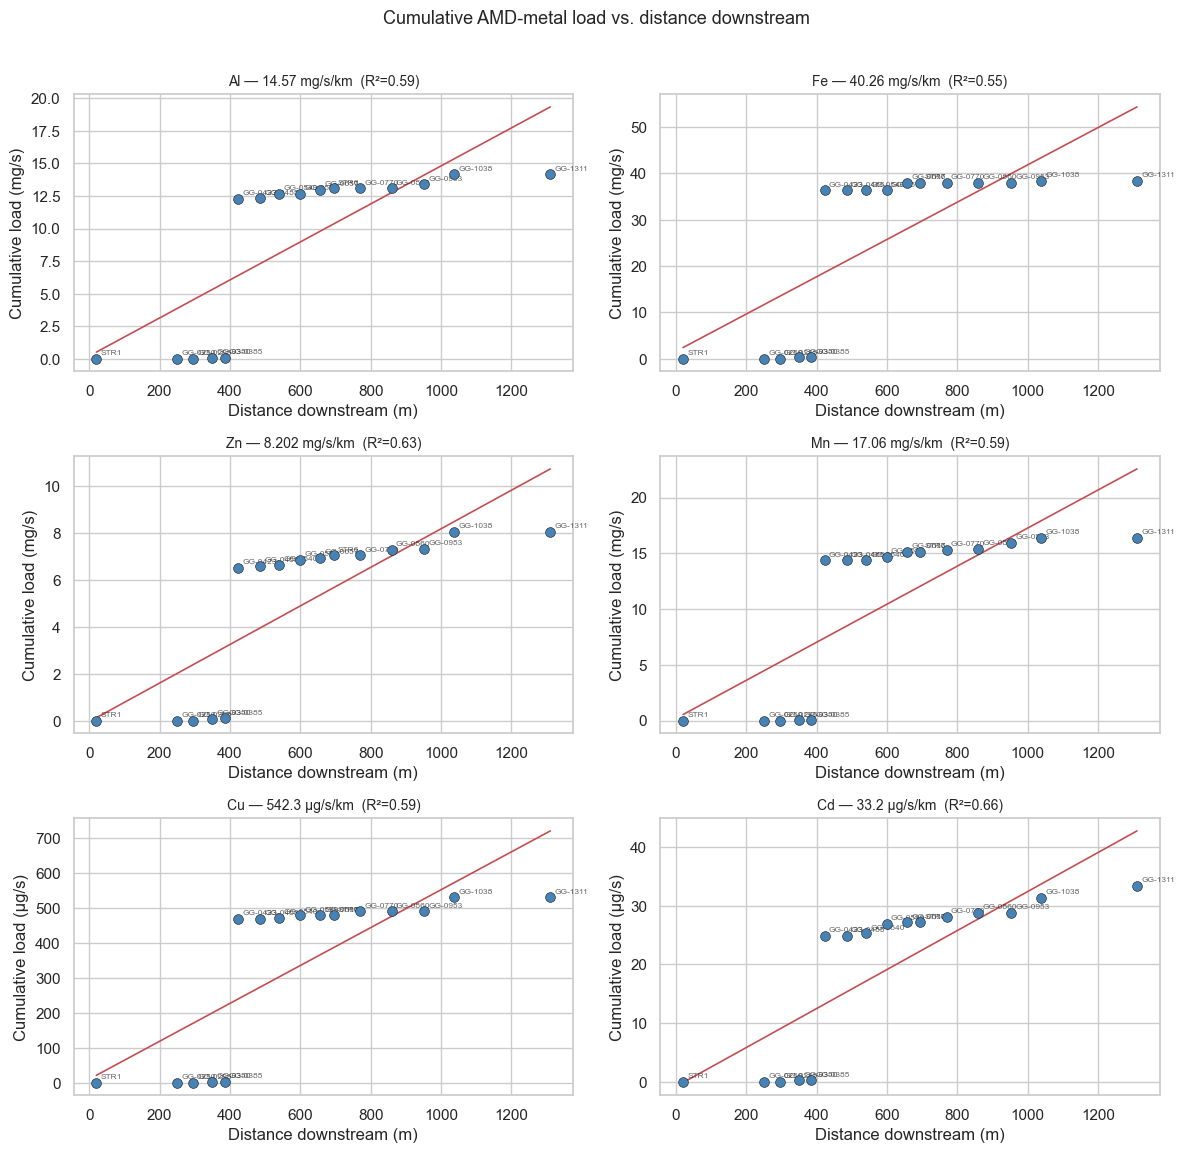

In [ ]:
# ── 11a. Cumulative load vs. distance — linear regression ──────────────────
load_metals = {
    "Al":  ("Al_cumulative_mg_s",   "Al_contribution_percent"),
    "Fe":  ("Fe_cumulative_mg_s",   "Fe_contribution_percent"),
    "Zn":  ("Zn_cumulative_mg_s",   "Zn_contribution_percent"),
    "Mn":  ("Mn_cumulative_mg_s",   "Mn_contribution_percent"),
    "Cu":  ("Cu_cumulative_ug_s",   "Cu_contribution_percent"),
    "Cd":  ("Cd_cumulative_ug_s",   "Cd_contribution_percent"),
}
# keep only metals whose columns actually exist
load_metals = {k: v for k, v in load_metals.items()
               if v[0] in loads.columns and v[1] in loads.columns}

ls = loads.sort_values("Dist_m").dropna(subset=["Dist_m"])

ncols = 2
nrows = (len(load_metals) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.8 * nrows))
axes = axes.flatten()

for ax, (metal, (cum_col, _)) in zip(axes, load_metals.items()):
    sub = ls.dropna(subset=[cum_col])
    if len(sub) < 2:
        ax.set_visible(False)
        continue
    ax.scatter(sub["Dist_m"], sub[cum_col], color="steelblue",
               s=50, edgecolors="k", linewidths=0.4, zorder=4)
    if len(sub) >= 2:
        m, b = np.polyfit(sub["Dist_m"], sub[cum_col], 1)
        xfit = np.linspace(sub["Dist_m"].min(), sub["Dist_m"].max(), 100)
        ax.plot(xfit, m * xfit + b, "r-", linewidth=1.2)
        ss_res = np.sum((sub[cum_col] - (m * sub["Dist_m"] + b))**2)
        ss_tot = np.sum((sub[cum_col] - sub[cum_col].mean())**2)
        r2 = 1 - ss_res / ss_tot if ss_tot != 0 else float("nan")
        unit = "mg/s" if cum_col.endswith("mg_s") else "µg/s"
        ax.set_title(f"{metal} — {m*1000:.4g} {unit}/km  (R²={r2:.2f})", fontsize=10)
    ax.set_xlabel("Distance downstream (m)")
    ax.set_ylabel(f"Cumulative load ({unit})")
    for i, row in sub.iterrows():
        ax.annotate(row["SiteID"], (row["Dist_m"], row[cum_col]),
                    fontsize=6, xytext=(3, 3), textcoords="offset points", alpha=0.7)

# Hide unused axes
for ax in axes[len(load_metals):]:
    ax.set_visible(False)

plt.suptitle("Cumulative AMD-metal load vs. distance downstream", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


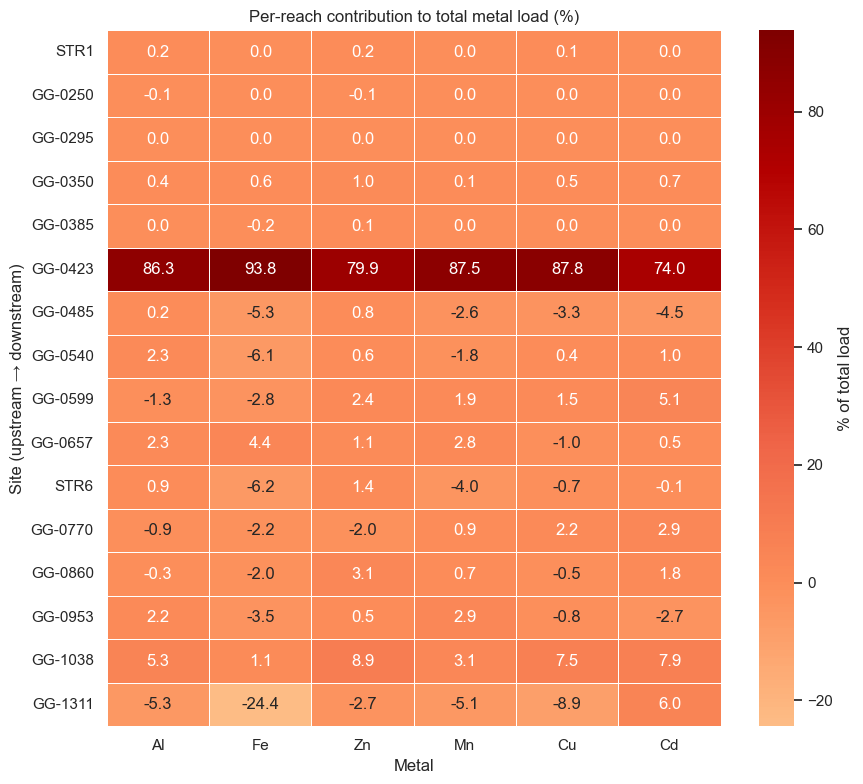

In [ ]:
# ── 11b. Per-reach contribution % — heatmap ────────────────────────────────
contrib_cols_avail = {k: v[1] for k, v in load_metals.items()
                      if v[1] in ls.columns}

if contrib_cols_avail:
    contrib_df = ls.set_index("SiteID")[[v for v in contrib_cols_avail.values()]]
    contrib_df.columns = list(contrib_cols_avail.keys())

    fig, ax = plt.subplots(figsize=(9, max(4, len(contrib_df) * 0.5)))
    sns.heatmap(contrib_df, cmap="OrRd", center=0, annot=True, fmt=".1f",
                linewidths=0.4, ax=ax, cbar_kws={"label": "% of total load"})
    ax.set_title("Per-reach contribution to total metal load (%)", fontsize=12)
    ax.set_xlabel("Metal")
    ax.set_ylabel("Site (upstream → downstream)")
    plt.tight_layout()
    plt.show()


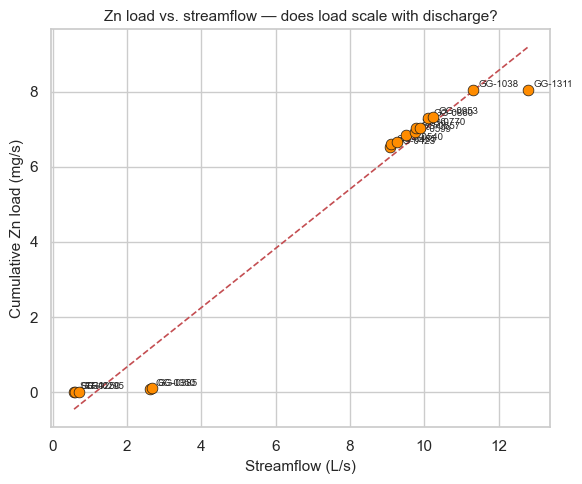

In [ ]:
# ── 11c. Zn cumulative load vs. streamflow ─────────────────────────────────
if "Zn_cumulative_mg_s" in ls.columns:
    zn_q = ls.dropna(subset=["Zn_cumulative_mg_s", "Streamflow_L_s"])
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(zn_q["Streamflow_L_s"], zn_q["Zn_cumulative_mg_s"],
               color="darkorange", s=60, edgecolors="k", linewidths=0.5, zorder=4)
    for _, row in zn_q.iterrows():
        ax.annotate(row["SiteID"], (row["Streamflow_L_s"], row["Zn_cumulative_mg_s"]),
                    fontsize=7, xytext=(4, 2), textcoords="offset points")
    if len(zn_q) >= 2:
        m, b = np.polyfit(zn_q["Streamflow_L_s"], zn_q["Zn_cumulative_mg_s"], 1)
        xf = np.linspace(zn_q["Streamflow_L_s"].min(), zn_q["Streamflow_L_s"].max(), 50)
        ax.plot(xf, m * xf + b, "r--", linewidth=1.2)
    ax.set_xlabel("Streamflow (L/s)", fontsize=11)
    ax.set_ylabel("Cumulative Zn load (mg/s)", fontsize=11)
    ax.set_title("Zn load vs. streamflow — does load scale with discharge?", fontsize=11)
    plt.tight_layout()
    plt.show()


## 12. Export cleaned & merged tables to Excel

A single `Perigo_Mine_clean.xlsx` workbook is written with one sheet per data
source table and an additional **Master** sheet that left-joins chemistry,
tracers, and site metadata on `SiteID`.


In [ ]:
import os

out_path = os.path.join(DATA_DIR, "Perigo_Mine_clean.xlsx")

# master join: start from chemistry, left-join tracers (first occurrence per SiteID),
# then left-join site metadata
tracers_dedup = tracers.drop_duplicates(subset="SiteID")
master = (chem
          .merge(tracers_dedup.drop(columns=["SiteType"], errors="ignore"),
                 on="SiteID", how="left", suffixes=("", "_tr"))
          .merge(sites.drop(columns=["SiteType"], errors="ignore"),
                 on="SiteID", how="left", suffixes=("", "_site")))

with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    sites.to_excel(writer,   sheet_name="Sites",      index=False)
    chem.to_excel(writer,    sheet_name="Chemistry",  index=False)
    tracers.to_excel(writer, sheet_name="Tracers",    index=False)
    slug_ts.to_excel(writer, sheet_name="SlugTS",     index=False)
    slug_res.to_excel(writer,sheet_name="SlugResults",index=False)
    loads.to_excel(writer,   sheet_name="Loads",      index=False)
    master.to_excel(writer,  sheet_name="Master",     index=False)

size_kb = os.path.getsize(out_path) / 1024
print(f"Wrote: {out_path}")
print(f"Size : {size_kb:.1f} kB")
print(f"Sheets: Sites, Chemistry, Tracers, SlugTS, SlugResults, Loads, Master")
print(f"Master sheet shape: {master.shape}")


Wrote: .\Perigo_Mine_clean.xlsx
Size : 227.3 kB
Sheets: Sites, Chemistry, Tracers, SlugTS, SlugResults, Loads, Master
Master sheet shape: (67, 192)
